---Grand Model Performance Tournament---
                      Model  R² Score  RMSE (Years)  MAE (Years)
                Extra Trees    0.8095          3.70         2.32
              Random Forest    0.8025          3.77         2.43
                    XGBoost    0.7966          3.82         2.50
     Hist Gradient Boosting    0.7936          3.85         2.60
                   LightGBM    0.7899          3.88         2.61
 Standard Gradient Boosting    0.7773          4.00         2.76
Stochastic Gradient Descent    0.7251          4.44         3.16
      Log-Linear Regression    0.7237          4.45         3.15


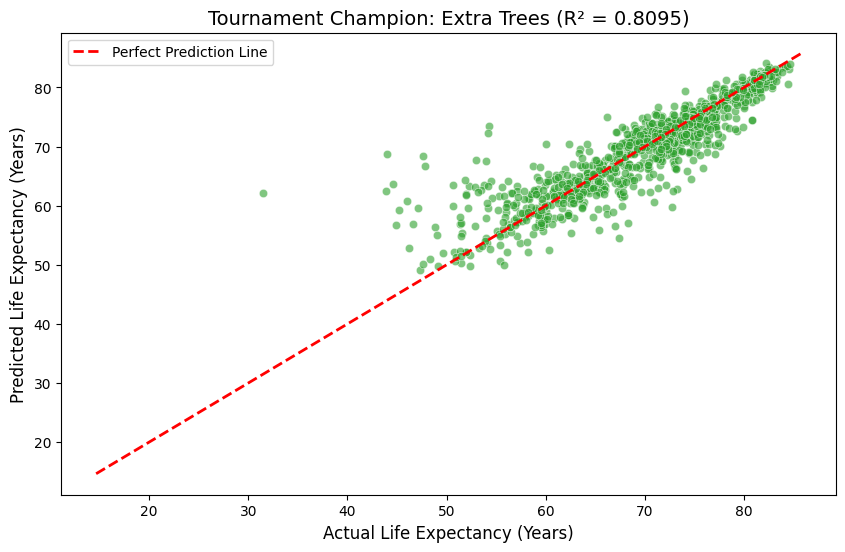

In [4]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Try importing XGBoost and LightGBM; fallback gracefully if not installed
try:
    from xgboost import XGBRegressor
    has_xgb = True
except ImportError:
    has_xgb = False

try:
    from lightgbm import LGBMRegressor
    has_lgbm = True
except ImportError:
    has_lgbm = False

# 1. Load All Features from Database
conn = sqlite3.connect("../database/healthcare.db", timeout=10)
query = """
SELECT country, year, life_expectancy, health_expenditure, gdp_per_capita, physicians_per_1000
FROM health_metrics
WHERE health_expenditure IS NOT NULL 
  AND gdp_per_capita IS NOT NULL 
  AND life_expectancy IS NOT NULL;
"""
df = pd.read_sql_query(query, conn)
conn.close()

# 2. Feature Engineering & Log Transformations
df["log_health_expenditure"] = np.log1p(df["health_expenditure"])
df["log_gdp_per_capita"] = np.log1p(df["gdp_per_capita"])
df["health_gdp_ratio"] = df["health_expenditure"] / df["gdp_per_capita"]

# Define Feature Matrix (X) and Target (y)
features = ["year", "log_health_expenditure", "log_gdp_per_capita", "health_gdp_ratio", "physicians_per_1000"]
X = df[features]
y = df["life_expectancy"]

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Impute Missing Physician Values (KNN) & Scale Features
imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# 5. Define 7 Competing Models
models = {
    "Log-Linear Regression": LinearRegression(),
    "Stochastic Gradient Descent": SGDRegressor(max_iter=1000, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "Standard Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42)
}

if has_xgb:
    models["XGBoost"] = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
if has_lgbm:
    models["LightGBM"] = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)

# 6. Benchmark Tournament
results = []
best_model_name = ""
best_r2 = -float("inf")
best_predictions = None

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        "Model": name,
        "R² Score": round(r2, 4),
        "RMSE (Years)": round(rmse, 2),
        "MAE (Years)": round(mae, 2)
    })
    
    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name
        best_predictions = y_pred

# 7. Print Leaderboard
results_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False)
print("---Grand Model Performance Tournament---")
print(results_df.to_string(index=False))

# 8. Plot Best Model Results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.6, color="#2ca02c")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Perfect Prediction Line")

plt.title(f"Tournament Champion: {best_model_name} (R² = {best_r2:.4f})", fontsize=14)
plt.xlabel("Actual Life Expectancy (Years)", fontsize=12)
plt.ylabel("Predicted Life Expectancy (Years)", fontsize=12)
plt.legend()
plt.savefig("../champion_ml_model_performance.png", bbox_inches='tight')
plt.show()